Classificação do Dataset Iris utilizando Support Vector Machine (SVM)

Objetivo: Este notebook realiza a leitura, Análise Exploratória de Dados (EDA), preparação e classificação das espécies de flores do dataset Iris utilizando algoritmo Support Vector Machine (SVM).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas do Scikitlearn
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/menegidio/iris-species/Iris.csv
/kaggle/input/datasets/menegidio/iris-species/database.sqlite


Obtenção dos Dados
Os dados são importados diretamente do diretório `/kaggle/input`. Vamos usar o Pandas para ler o arquivo `Iris.csv` disponibilizado.

In [2]:

caminho_arquivo = '/kaggle/input/datasets/menegidio/iris-species/Iris.csv' 
df = pd.read_csv(caminho_arquivo)

# Removi a coluna 'Id' se ela existir, pois não tem valor preditivo, podendo facilitar a svm
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


 Análise Exploratória de Dados (EDA)
Aqui precisamos entender a estrutura do dataset, verificar se existem valores nulos e analisar a distribuição das features (comprimento e largura de pétalas e sépalas) em relação a cada espécie (`Species`).

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
--------------------------------------------------
       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count     150.000000    150.000000     150.000000    150.000000
mean        5.843333      3.054000       3.758667      1.198667
std         0.828066      0.433594       1.764420      0.763161
min         4.300000      2.000000       1.000000      0.100000
25%         5.100000      2.800000       1.600000      0.300000
50%         5.800000      3.000000       4.350000      1.300000
75%         6.400000      3.3000

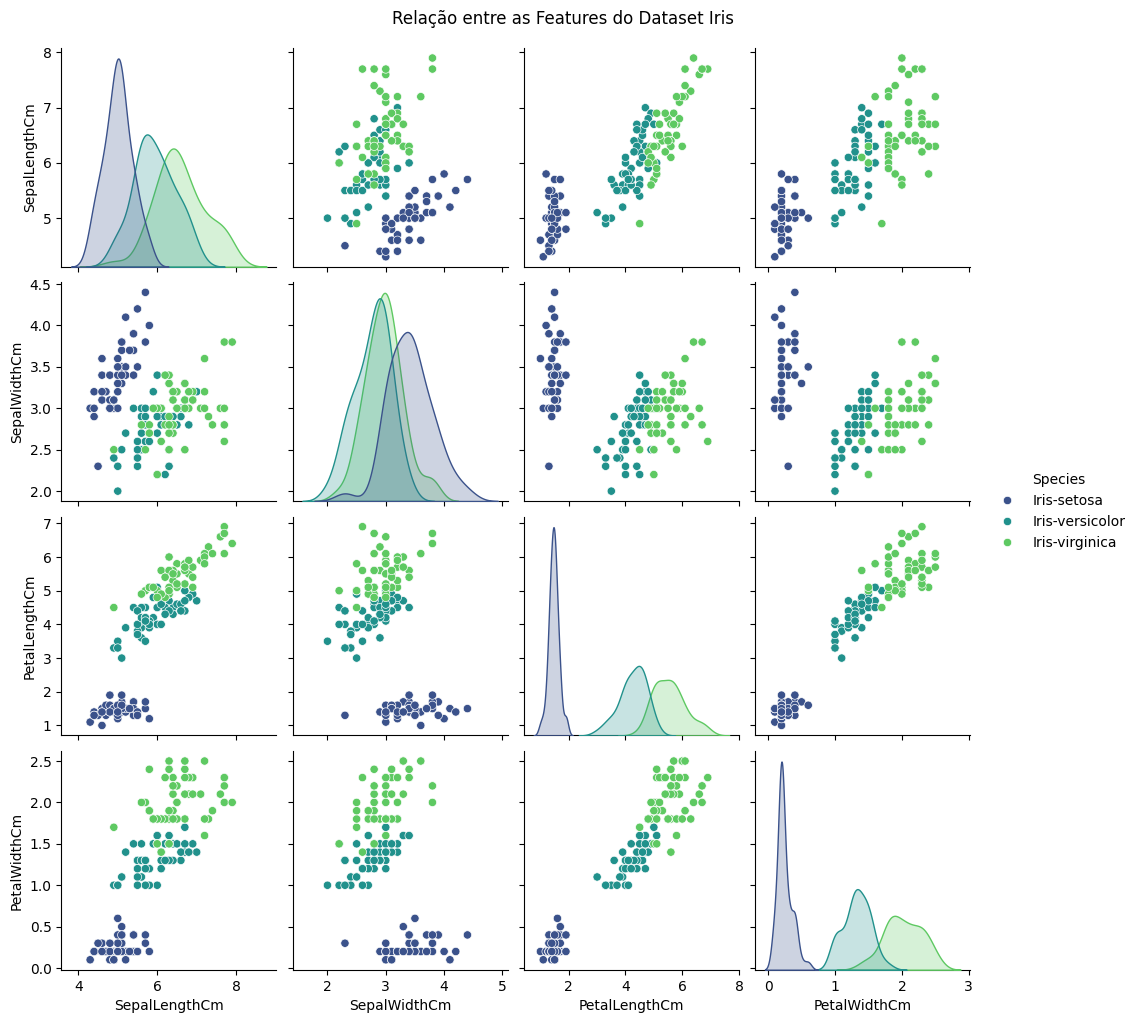

In [3]:
 #dados e valores nulos
print(df.info())
print("-" * 50)
# Estatísticas
print(df.describe())

# relação entre as variáveis
sns.pairplot(df, hue='Species', palette='viridis')
plt.suptitle('Relação entre as Features do Dataset Iris', y=1.02)
plt.show()

 Preparação dos Dados
COmo treino do modelo de Machine Learning, vou separar o dataset em variáveis independentes (Features - X) e a variável dependente (Target - y). Após isso vou dividir os dados em conjuntos de treino (80%) e teste (20%) para garantir uma avaliação justa do modelo.

In [4]:
# Separando X (features) e y (target)
X = df.drop('Species', axis=1)
y = df['Species']

# Divisão do treino (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamanho do conjunto de treino: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]} amostras")

Tamanho do conjunto de treino: 120 amostras
Tamanho do conjunto de teste: 30 amostras


Criação do Modelo (SVM)
o modelo de classificação será construído utilizando o SVM. O objetivo do SVM é encontrar o hiperplano que melhor separa as classes no espaço de features.

In [5]:
# Instanciando o modelo SVM
svm_model = SVC(kernel='linear', random_state=42)

# treinando o modelo com os dados de treino
svm_model.fit(X_train, y_train)

# Realizando previsões com os dados de teste
y_pred = svm_model.predict(X_test)

Avaliação dos Resultados
Para avaliar o desempenho do SVM, vou utilizar métricas clássicas de classificação:
a Acurácia, o Classification Report e a Matriz de Confusão.

Acurácia:para medir o percentual total de acertos.
Matriz de Confusão: apresentar os acertos e erros do modelo divididos por cada classe.

Acurácia do Modelo: 100.00%

Relatório de Classificação:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



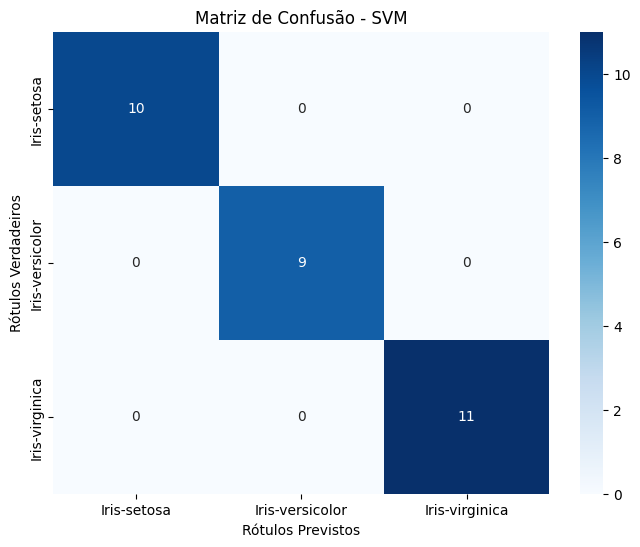

In [6]:
# Calculo a acurácia
acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia do Modelo: {acuracia * 100:.2f}%\n")

#  o classification report
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))

#  a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g', 
            xticklabels=svm_model.classes_, 
            yticklabels=svm_model.classes_)
plt.xlabel('Rótulos Previstos')
plt.ylabel('Rótulos Verdadeiros')
plt.title('Matriz de Confusão - SVM')
plt.show()